Random vectors

In [1]:
from pathlib import Path
import re
import time
import random

import pandas as pd
import numpy as np


In [2]:
# ============================================================
# C880 Scenario 1 Configuration
# ============================================================

BENCH_FILE = Path("../fsim-contest.github/fsim-contest.github/data.nogit/c880.bench")
FAULT_FILE = Path("c880_equivalent_collapsed_saf.txt")

N_VECTORS = 1024

RANDOM_SEED = 42

# C880 is expected to have:
EXPECTED_PI_COUNT = 60
EXPECTED_PO_COUNT = 26


In [3]:
class Gate:
    def __init__(self, output, gate_type, inputs):
        self.output = str(output)
        self.gate_type = gate_type.upper()
        self.inputs = [str(x) for x in inputs]

    def __repr__(self):
        return f"Gate({self.output} = {self.gate_type}({', '.join(self.inputs)}))"


class Circuit:
    def __init__(self):
        self.inputs = []
        self.outputs = []
        self.gates = []

        # Quick lookup
        self.gate_by_output = {}

        # Evaluation order
        self.eval_order = []

    def __repr__(self):
        return (
            f"Circuit("
            f"PIs={len(self.inputs)}, "
            f"POs={len(self.outputs)}, "
            f"gates={len(self.gates)})"
        )


In [4]:
def parse_bench_file(filename):
    """
    Parse an ISCAS .bench combinational circuit.

    Returns
    -------
    Circuit
        Parsed circuit representation.
    """

    circuit = Circuit()

    input_re = re.compile(r"^\s*INPUT\s*\(\s*([^)]+)\s*\)\s*$", re.IGNORECASE)
    output_re = re.compile(r"^\s*OUTPUT\s*\(\s*([^)]+)\s*\)\s*$", re.IGNORECASE)

    gate_re = re.compile(
        r"^\s*([^\s=]+)\s*=\s*([A-Za-z0-9_]+)\s*\((.*?)\)\s*$"
    )

    with open(filename, "r") as f:
        for line_number, raw_line in enumerate(f, start=1):

            # Remove comments
            line = raw_line.split("#", 1)[0].strip()

            if not line:
                continue

            # INPUT
            match = input_re.match(line)
            if match:
                signal = match.group(1).strip()
                circuit.inputs.append(signal)
                continue

            # OUTPUT
            match = output_re.match(line)
            if match:
                signal = match.group(1).strip()
                circuit.outputs.append(signal)
                continue

            # Gate assignment
            match = gate_re.match(line)
            if match:
                output_signal = match.group(1).strip()
                gate_type = match.group(2).strip().upper()

                input_string = match.group(3).strip()

                if input_string:
                    gate_inputs = [
                        x.strip()
                        for x in input_string.split(",")
                    ]
                else:
                    gate_inputs = []

                gate = Gate(
                    output=output_signal,
                    gate_type=gate_type,
                    inputs=gate_inputs
                )

                circuit.gates.append(gate)
                circuit.gate_by_output[output_signal] = gate

                continue

            raise ValueError(
                f"Could not parse line {line_number}: {raw_line.rstrip()}"
            )

    return circuit


In [5]:
circuit = parse_bench_file(BENCH_FILE)
print(circuit)
print("Primary inputs :", len(circuit.inputs))
print("Primary outputs:", len(circuit.outputs))
print("Gates          :", len(circuit.gates))

assert len(circuit.inputs) == EXPECTED_PI_COUNT, (
    f"Expected {EXPECTED_PI_COUNT} inputs, "
    f"found {len(circuit.inputs)}"
)

assert len(circuit.outputs) == EXPECTED_PO_COUNT, (
    f"Expected {EXPECTED_PO_COUNT} outputs, "
    f"found {len(circuit.outputs)}"
)

print("\nC880 interface validation PASSED.")


Circuit(PIs=60, POs=26, gates=383)
Primary inputs : 60
Primary outputs: 26
Gates          : 383

C880 interface validation PASSED.


In [6]:
def build_evaluation_order(circuit):
    """
    Topologically sort the combinational gates.

    Primary inputs are assumed to be already available.
    """

    input_set = set(circuit.inputs)

    remaining = list(circuit.gates)

    known = set(input_set)
    ordered_gates = []

    while remaining:

        progress = False
        next_remaining = []

        for gate in remaining:

            if all(signal in known for signal in gate.inputs):
                ordered_gates.append(gate)
                known.add(gate.output)
                progress = True
            else:
                next_remaining.append(gate)

        if not progress:
            unresolved = [
                {
                    "output": gate.output,
                    "type": gate.gate_type,
                    "inputs": gate.inputs
                }
                for gate in next_remaining
            ]

            raise RuntimeError(
                "Unable to establish topological order. "
                "Possible missing signal or combinational loop.\n"
                f"Unresolved gates: {unresolved[:10]}"
            )

        remaining = next_remaining

    circuit.eval_order = ordered_gates

    return ordered_gates


In [7]:
eval_order = build_evaluation_order(circuit)

print("Evaluation order established.")
print("Number of gates:", len(eval_order))


Evaluation order established.
Number of gates: 383


In [8]:
def validate_circuit_signals(circuit):
    """
    Verify that every gate input refers to either:
      - a primary input, or
      - an existing gate output.
    """

    defined = set(circuit.inputs)

    problems = []

    for gate in circuit.gates:
        for signal in gate.inputs:
            if signal not in defined:
                problems.append({
                    "gate_output": gate.output,
                    "gate_type": gate.gate_type,
                    "missing_input": signal
                })

        defined.add(gate.output)

    # Check outputs
    missing_outputs = [
        output
        for output in circuit.outputs
        if output not in defined
    ]

    return problems, missing_outputs


In [9]:
problems, missing_outputs = validate_circuit_signals(circuit)

print("Missing gate-input references:", len(problems))
print("Missing outputs:", len(missing_outputs))

if problems:
    print(problems[:10])

if missing_outputs:
    print(missing_outputs)


Missing gate-input references: 0
Missing outputs: 0


In [10]:
def evaluate_gate(gate_type, values):
    """
    Evaluate a logic gate.

    Parameters
    ----------
    gate_type : str
        Gate type such as AND, NAND, OR, NOR, NOT, BUF.
    values : list[int]
        Binary input values.

    Returns
    -------
    int
        Binary output.
    """

    gate_type = gate_type.upper()
    values = [int(v) for v in values]

    if gate_type == "AND":
        return int(all(values))

    elif gate_type == "NAND":
        return int(not all(values))

    elif gate_type == "OR":
        return int(any(values))

    elif gate_type == "NOR":
        return int(not any(values))

    elif gate_type in {"NOT", "INV", "INVERTER"}:
        if len(values) != 1:
            raise ValueError(
                f"{gate_type} expects one input, got {len(values)}"
            )
        return int(not values[0])

    elif gate_type in {"BUFF", "BUFFER"}:
        if len(values) != 1:
            raise ValueError(
                f"{gate_type} expects one input, got {len(values)}"
            )
        return values[0]

    else:
        raise ValueError(f"Unsupported gate type: {gate_type}")


In [11]:
def simulate_circuit(circuit, input_vector):
    """
    Simulate the good C880 circuit.

    Parameters
    ----------
    circuit : Circuit
    input_vector : dict
        Mapping:
            signal -> 0/1

    Returns
    -------
    dict
        All signal values after simulation.
    """

    if set(input_vector.keys()) != set(circuit.inputs):
        missing = set(circuit.inputs) - set(input_vector.keys())
        extra = set(input_vector.keys()) - set(circuit.inputs)

        raise ValueError(
            f"Input mismatch. Missing={missing}, Extra={extra}"
        )

    values = {
        str(signal): int(value)
        for signal, value in input_vector.items()
    }

    for gate in circuit.eval_order:

        input_values = [
            values[signal]
            for signal in gate.inputs
        ]

        values[gate.output] = evaluate_gate(
            gate.gate_type,
            input_values
        )

    return values


In [12]:
def get_po_vector(circuit, signal_values):
    """
    Return PO values in exactly the order defined
    by OUTPUT declarations in the .bench file.
    """

    return [
        signal_values[po]
        for po in circuit.outputs
    ]
def po_vector_to_string(po_vector):
    return "".join(str(int(x)) for x in po_vector)


In [13]:
test_vector = {
    signal: 0
    for signal in circuit.inputs
}

signal_values = simulate_circuit(
    circuit,
    test_vector
)

po_vector = get_po_vector(
    circuit,
    signal_values
)

print("Input vector:")
print("".join(str(test_vector[x]) for x in circuit.inputs))

print("\nPO vector:")
print(po_vector_to_string(po_vector))

print("\nPO count:", len(po_vector))


Input vector:
000000000000000000000000000000000000000000000000000000000000

PO vector:
00000111101000000000000000

PO count: 26


In [14]:
def generate_random_vectors(circuit, n_vectors, seed=42):
    """
    Generate unique uniform-random binary vectors.

    Returns
    -------
    list[dict]
        List of input dictionaries.
    """

    rng = random.Random(seed)

    vectors = []
    seen = set()

    while len(vectors) < n_vectors:

        bits = tuple(
            rng.randint(0, 1)
            for _ in circuit.inputs
        )

        if bits in seen:
            continue

        seen.add(bits)

        vector = {
            signal: bit
            for signal, bit in zip(circuit.inputs, bits)
        }

        vectors.append(vector)

    return vectors

random_vectors = generate_random_vectors(
    circuit,
    N_VECTORS,
    seed=RANDOM_SEED
)

print("Generated vectors:", len(random_vectors))


Generated vectors: 1024


In [15]:
vector_strings = [
    "".join(str(v[signal]) for signal in circuit.inputs)
    for v in random_vectors
]

print("Total vectors :", len(vector_strings))
print("Unique vectors:", len(set(vector_strings)))

assert len(vector_strings) == len(set(vector_strings))

print("Vector uniqueness validation PASSED.")


Total vectors : 1024
Unique vectors: 1024
Vector uniqueness validation PASSED.


In [16]:
results = []

simulation_start = time.perf_counter()

for vector_id, input_vector in enumerate(random_vectors, start=1):

    start = time.perf_counter()

    signal_values = simulate_circuit(
        circuit,
        input_vector
    )

    po_vector = get_po_vector(
        circuit,
        signal_values
    )

    elapsed = time.perf_counter() - start

    input_bits = "".join(
        str(input_vector[signal])
        for signal in circuit.inputs
    )

    po_bits = po_vector_to_string(po_vector)

    results.append({
        "vector_id": vector_id,
        "input_vector": input_bits,
        "po_vector": po_bits,
        "simulation_time_s": elapsed
    })

total_simulation_time = time.perf_counter() - simulation_start

print(f"Simulated {len(results)} vectors.")
print(f"Total simulation time: {total_simulation_time:.6f} s")


Simulated 1024 vectors.
Total simulation time: 0.937198 s


In [17]:
results_df = pd.DataFrame(results)

results_df.head()


,vector_id,input_vector,po_vector,simulation_time_s
0,1,0010000010000000101100111001001011101010110000...,00000111111000011111110110,0.001868
1,2,0001110100011100101110100111100100000101111001...,00000111111000011011101111,0.003521
2,3,0011001100000100010110011111000010000000001001...,00000111101000001011101111,0.000520
3,4,1000110000101011001000000111010010111111001000...,00000111101000010111001000,0.002112
4,5,0011101011011100100010100110110100100011010111...,00000111111000010110101000,0.000557


In [18]:
po_columns = [
    f"PO_{po}"
    for po in circuit.outputs
]

po_data = []

for result in results:

    row = {
        "vector_id": result["vector_id"],
        "input_vector": result["input_vector"],
    }

    for po_name, value in zip(
        circuit.outputs,
        map(int, result["po_vector"])
    ):
        row[f"PO_{po_name}"] = value

    po_data.append(row)

po_df = pd.DataFrame(po_data)

po_df.head()


,vector_id,input_vector,PO_388,PO_389,PO_390,PO_391,PO_418,PO_419,PO_420,PO_421,...,PO_768,PO_850,PO_863,PO_864,PO_865,PO_866,PO_874,PO_878,PO_879,PO_880
0,1,0010000010000000101100111001001011101010110000...,0,0,0,0,0,1,1,1,...,1,1,1,1,1,1,0,1,1,0
1,2,0001110100011100101110100111100100000101111001...,0,0,0,0,0,1,1,1,...,1,0,1,1,1,0,1,1,1,1
2,3,0011001100000100010110011111000010000000001001...,0,0,0,0,0,1,1,1,...,1,0,1,1,1,0,1,1,1,1
3,4,1000110000101011001000000111010010111111001000...,0,0,0,0,0,1,1,1,...,0,1,1,1,0,0,1,0,0,0
4,5,0011101011011100100010100110110100100011010111...,0,0,0,0,0,1,1,1,...,0,1,1,0,1,0,1,0,0,0


In [19]:
print("==========================================")
print("C880 SCENARIO 1 — RANDOM PATTERN TESTING")
print("==========================================")

print(f"Primary inputs : {len(circuit.inputs)}")
print(f"Primary outputs: {len(circuit.outputs)}")
print(f"Vectors        : {len(results_df)}")
print(f"Random seed    : {RANDOM_SEED}")
print(f"Simulation time: {total_simulation_time:.6f} s")

print("\nFirst 10 vectors:")
display(results_df.head(10))


C880 SCENARIO 1 — RANDOM PATTERN TESTING
Primary inputs : 60
Primary outputs: 26
Vectors        : 1024
Random seed    : 42
Simulation time: 0.937198 s

First 10 vectors:


,vector_id,input_vector,po_vector,simulation_time_s
0,1,0010000010000000101100111001001011101010110000...,00000111111000011111110110,0.001868
1,2,0001110100011100101110100111100100000101111001...,00000111111000011011101111,0.003521
2,3,0011001100000100010110011111000010000000001001...,00000111101000001011101111,0.000520
3,4,1000110000101011001000000111010010111111001000...,00000111101000010111001000,0.002112
4,5,0011101011011100100010100110110100100011010111...,00000111111000010110101000,0.000557
5,6,0001010011010001100001001101001010011100001110...,00000111101000010101101101,0.005055
6,7,1010101001101101111110011011011011111010011001...,00010100101000011101000000,0.001751
7,8,0000100100010111110111011011010111000010001111...,00000111101000110111000011,0.000529
8,9,1011101110100100101001110111111101001000000000...,00000010001100000100100011,0.001217
9,10,1100001001110101101110101111110011011101101011...,00000100111000011100111100,0.000568


In [20]:
results_df.to_csv(
    "c880_scenario1_good_circuit_results.csv",
    index=False
)

po_df.to_csv(
    "c880_scenario1_po_values.csv",
    index=False
)

print("Results saved.")


Results saved.


In [21]:
from dataclasses import dataclass


@dataclass(frozen=True)
class Fault:
    fault_id: int
    source: str
    location: str
    fault_type: str
    is_branch: bool

    @property
    def name(self):
        if self.is_branch:
            return f"{self.source}->{self.location}/{self.fault_type}"
        return f"{self.location}/{self.fault_type}"

    def __repr__(self):
        return (
            f"Fault("
            f"{self.name}, "
            f"branch={self.is_branch})"
        )


In [22]:
def parse_fault_line(line, fault_id):
    """
    Parse one collapsed-fault line.

    Supported formats:

        1/SA0
        1/SA1
        1->269/SA1
        101->303/SA0
    """

    line = line.strip()

    if not line or line.startswith("#"):
        return None

    # Branch fault:
    # source -> location / SA0 or SA1
    branch_match = re.fullmatch(
        r"\s*([A-Za-z0-9_]+)\s*->\s*([A-Za-z0-9_]+)\s*/\s*(SA[01])\s*",
        line,
        re.IGNORECASE
    )

    if branch_match:
        source = branch_match.group(1)
        location = branch_match.group(2)
        fault_type = branch_match.group(3).upper()

        return Fault(
            fault_id=fault_id,
            source=source,
            location=location,
            fault_type=fault_type,
            is_branch=True
        )

    # Stem/node fault:
    # location / SA0 or SA1
    stem_match = re.fullmatch(
        r"\s*([A-Za-z0-9_]+)\s*/\s*(SA[01])\s*",
        line,
        re.IGNORECASE
    )

    if stem_match:
        location = stem_match.group(1)
        fault_type = stem_match.group(2).upper()

        return Fault(
            fault_id=fault_id,
            source=location,
            location=location,
            fault_type=fault_type,
            is_branch=False
        )

    raise ValueError(f"Unrecognized fault format: {line}")


In [23]:
def load_fault_file(filename):
    faults = []

    with open(filename, "r") as f:
        for line in f:
            line = line.strip()

            if not line or line.startswith("#"):
                continue

            fault = parse_fault_line(
                line,
                fault_id=len(faults) + 1
            )

            if fault is not None:
                faults.append(fault)

    return faults


In [24]:
FAULT_FILE = Path("c880_equivalence_collapsed_saf.txt")

faults = load_fault_file(FAULT_FILE)

print("Total faults:", len(faults))


Total faults: 994


In [25]:
for fault in faults[:20]:
    print(fault)


Fault(1->269/SA1, branch=True)
Fault(1->270/SA1, branch=True)
Fault(1->276/SA1, branch=True)
Fault(1->279/SA1, branch=True)
Fault(1->280/SA1, branch=True)
Fault(1->483/SA1, branch=True)
Fault(1/SA0, branch=False)
Fault(1/SA1, branch=False)
Fault(101->303/SA1, branch=True)
Fault(101->304/SA0, branch=True)
Fault(101->334/SA1, branch=True)
Fault(101->506/SA1, branch=True)
Fault(101/SA0, branch=False)
Fault(101/SA1, branch=False)
Fault(106->303/SA1, branch=True)
Fault(106->304/SA0, branch=True)
Fault(106->335/SA1, branch=True)
Fault(106->508/SA1, branch=True)
Fault(106/SA0, branch=False)
Fault(106/SA1, branch=False)


In [26]:
def validate_faults(circuit, faults):
    signal_names = set(circuit.inputs)

    for gate in circuit.gates:
        signal_names.add(gate.output)

    errors = []

    for fault in faults:

        if fault.source not in signal_names:
            errors.append(
                f"{fault.name}: source '{fault.source}' "
                f"does not exist"
            )

        if fault.location not in signal_names:
            errors.append(
                f"{fault.name}: location '{fault.location}' "
                f"does not exist"
            )

        if fault.is_branch:

            gate = circuit.gate_by_output.get(fault.location)

            if gate is None:
                errors.append(
                    f"{fault.name}: branch destination "
                    f"'{fault.location}' is not a gate output"
                )

            elif fault.source not in gate.inputs:
                errors.append(
                    f"{fault.name}: source '{fault.source}' "
                    f"is not an input of gate '{fault.location}'"
                )

    return errors


In [27]:
fault_errors = validate_faults(circuit, faults)

print("Fault validation errors:", len(fault_errors))

if fault_errors:
    for error in fault_errors[:20]:
        print(error)
else:
    print("All faults successfully mapped to C880.")


Fault validation errors: 0
All faults successfully mapped to C880.


In [28]:
def simulate_circuit_with_fault(
    circuit,
    input_vector,
    fault=None
):
    """
    Simulate the circuit with optional single stuck-at fault.

    Supports:
        - stem faults: signal/SA0 or signal/SA1
        - branch faults: source->gate/SA0 or source->gate/SA1
    """

    values = {
        str(signal): int(value)
        for signal, value in input_vector.items()
    }

    for gate in circuit.eval_order:

        input_values = []

        for source_signal in gate.inputs:

            value = values[source_signal]

            if fault is not None:

                # ------------------------------------------------
                # Stem fault
                # ------------------------------------------------
                if (
                    not fault.is_branch
                    and source_signal == fault.location
                ):
                    value = (
                        0
                        if fault.fault_type == "SA0"
                        else 1
                    )

                # ------------------------------------------------
                # Branch fault
                # ------------------------------------------------
                elif (
                    fault.is_branch
                    and source_signal == fault.source
                    and gate.output == fault.location
                ):
                    value = (
                        0
                        if fault.fault_type == "SA0"
                        else 1
                    )

            input_values.append(value)

        values[gate.output] = evaluate_gate(
            gate.gate_type,
            input_values
        )

    return values


In [29]:
def compare_po_vectors(good_po, faulty_po, po_names):
    """
    Compare good and faulty PO vectors.
    """

    mismatching_pos = [
        po
        for po, good, faulty in zip(
            po_names,
            good_po,
            faulty_po
        )
        if good != faulty
    ]

    return {
        "detected": len(mismatching_pos) > 0,
        "mismatch_count": len(mismatching_pos),
        "mismatching_pos": mismatching_pos
    }


In [30]:
def simulate_fault(
    circuit,
    input_vector,
    fault,
    good_po
):
    """
    Simulate good and faulty circuits and compare POs.
    """

    # # Good circuit
    # good_values = simulate_circuit_with_fault(
    #     circuit,
    #     input_vector,
    #     fault=None
    # )

    # good_po = get_po_vector(
    #     circuit,
    #     good_values
    # )

    # Faulty circuit
    faulty_values = simulate_circuit_with_fault(
        circuit,
        input_vector,
        fault=fault
    )

    faulty_po = get_po_vector(
        circuit,
        faulty_values
    )

    comparison = compare_po_vectors(
        good_po,
        faulty_po,
        circuit.outputs
    )

    return {
        "good_po": good_po,
        "faulty_po": faulty_po,
        **comparison
    }


In [31]:
def simulate_faulty_circuit(
    circuit,
    input_vector,
    fault
):
    """
    Simulate only the faulty circuit.

    The good circuit response should be cached separately
    and reused for all faults for the same input vector.
    """

    faulty_values = simulate_circuit_with_fault(
        circuit,
        input_vector,
        fault=fault
    )

    faulty_po = get_po_vector(
        circuit,
        faulty_values
    )

    return faulty_po


In [32]:
# test_fault = next(
#     fault
#     for fault in faults
#     if fault.name == "1/SA0"
# )

# test_vector = random_vectors[0]

# fault_result = simulate_fault(
#     circuit,
#     test_vector,
#     test_fault
# )

# print("Fault:", test_fault.name)

# print(
#     "Good PO:  ",
#     po_vector_to_string(fault_result["good_po"])
# )

# print(
#     "Faulty PO:",
#     po_vector_to_string(fault_result["faulty_po"])
# )

# print("Detected:", fault_result["detected"])
# print("Mismatch count:", fault_result["mismatch_count"])
# print("Mismatching POs:", fault_result["mismatching_pos"])


In [33]:
# branch_fault = next(
#     fault
#     for fault in faults
#     if fault.name == "1->269/SA1"
# )

# branch_result = simulate_fault(
#     circuit,
#     test_vector,
#     branch_fault
# )

# print("Fault:", branch_fault.name)

# print(
#     "Good PO:  ",
#     po_vector_to_string(branch_result["good_po"])
# )

# print(
#     "Faulty PO:",
#     po_vector_to_string(branch_result["faulty_po"])
# )

# print("Detected:", branch_result["detected"])
# print("Mismatch count:", branch_result["mismatch_count"])
# print("Mismatching POs:", branch_result["mismatching_pos"])


In [34]:
def get_gate_input_values(
    circuit,
    input_vector,
    gate_output,
    fault=None
):
    values = {
        str(signal): int(value)
        for signal, value in input_vector.items()
    }

    gate = circuit.gate_by_output[gate_output]

    for current_gate in circuit.eval_order:

        input_values = []

        for source_signal in current_gate.inputs:

            value = values[source_signal]

            if fault is not None:

                if (
                    not fault.is_branch
                    and source_signal == fault.location
                ):
                    value = (
                        0
                        if fault.fault_type == "SA0"
                        else 1
                    )

                elif (
                    fault.is_branch
                    and source_signal == fault.source
                    and current_gate.output == fault.location
                ):
                    value = (
                        0
                        if fault.fault_type == "SA0"
                        else 1
                    )

            input_values.append(value)

        values[current_gate.output] = evaluate_gate(
            current_gate.gate_type,
            input_values
        )

        if current_gate.output == gate_output:
            return dict(zip(
                current_gate.inputs,
                input_values
            ))

    raise ValueError(f"Gate {gate_output} not found")


In [37]:
good_inputs = get_gate_input_values(
    circuit,
    test_vector,
    "269"
)

print("Good gate inputs:")
print(good_inputs)

# faulty_inputs = get_gate_input_values(
#     circuit,
#     test_vector,
#     "269",
#     branch_fault
# )


# print("\nFaulty gate inputs:")
# print(faulty_inputs)


Good gate inputs:
{'1': 0, '8': 0, '13': 0, '17': 0}


In [70]:
# fault_results = []

# experiment_start = time.perf_counter()

# for vector_id, input_vector in enumerate(
#     random_vectors,
#     start=1
# ):

#     for fault in faults:

#         result = simulate_fault(
#             circuit,
#             input_vector,
#             fault
#         )

#         fault_results.append({
#             "vector_id": vector_id,
#             "fault_id": fault.fault_id,
#             "fault": fault.name,
#             "fault_type": fault.fault_type,
#             "is_branch": fault.is_branch,
#             "good_po": po_vector_to_string(
#                 result["good_po"]
#             ),
#             "faulty_po": po_vector_to_string(
#                 result["faulty_po"]
#             ),
#             "detected": result["detected"],
#             "mismatch_count": result["mismatch_count"],
#             "mismatching_pos": ",".join(
#                 result["mismatching_pos"]
#             )
#         })

# experiment_time = (
#     time.perf_counter() - experiment_start
# )

# print(
#     f"Fault simulation completed in "
#     f"{experiment_time:.3f} seconds"
# )

# print(
#     f"Total fault/vector simulations: "
#     f"{len(fault_results):,}"
# )

fault_results = []

experiment_start = time.perf_counter()

# ---------------------------------------------------------
# Cache the GOOD circuit response once per vector
# ---------------------------------------------------------

good_po_cache = {}

good_simulation_start = time.perf_counter()

for vector_id, input_vector in enumerate(
    random_vectors,
    start=1
):

    good_values = simulate_circuit(
        circuit,
        input_vector
    )

    good_po = get_po_vector(
        circuit,
        good_values
    )

    good_po_cache[vector_id] = good_po

good_simulation_time = (
    time.perf_counter() - good_simulation_start
)

print(
    f"Good-circuit simulations: {len(random_vectors):,}"
)

print(
    f"Good-circuit simulation time: "
    f"{good_simulation_time:.3f} seconds"
)


# ---------------------------------------------------------
# Fault simulation
# ---------------------------------------------------------

fault_simulation_start = time.perf_counter()

for vector_id, input_vector in enumerate(
    random_vectors,
    start=1
):

    # Reuse cached good response
    good_po = good_po_cache[vector_id]

    for fault in faults:

        # Only simulate the FAULTY circuit here
        faulty_values = simulate_circuit_with_fault(
            circuit,
            input_vector,
            fault=fault
        )

        faulty_po = get_po_vector(
            circuit,
            faulty_values
        )

        comparison = compare_po_vectors(
            good_po,
            faulty_po,
            circuit.outputs
        )

        fault_results.append({
            "vector_id": vector_id,
            "fault_id": fault.fault_id,
            "fault": fault.name,
            "fault_type": fault.fault_type,
            "source": fault.source,
            "location": fault.location,
            "is_branch": fault.is_branch,

            "good_po": po_vector_to_string(
                good_po
            ),

            "faulty_po": po_vector_to_string(
                faulty_po
            ),

            "detected": comparison["detected"],

            "mismatch_count": comparison[
                "mismatch_count"
            ],

            "mismatching_pos": ",".join(
                comparison["mismatching_pos"]
            )
        })


fault_simulation_time = (
    time.perf_counter() - fault_simulation_start
)

experiment_time = (
    time.perf_counter() - experiment_start
)

print(
    f"Fault simulation completed in "
    f"{fault_simulation_time:.3f} seconds"
)

print(
    f"Total experiment time: "
    f"{experiment_time:.3f} seconds"
)

print(
    f"Total fault/vector simulations: "
    f"{len(fault_results):,}"
)


Good-circuit simulations: 1,024
Good-circuit simulation time: 0.718 seconds
Fault simulation completed in 355.619 seconds
Total experiment time: 356.338 seconds
Total fault/vector simulations: 1,017,856


In [39]:
fault_results_df = pd.DataFrame(
    fault_results
)

fault_summary = (
    fault_results_df
    .groupby(
        [
            "fault_id",
            "fault",
            "fault_type",
            "source",
            "location",
            "is_branch"
        ],
        as_index=False
    )
    .agg(
        first_detecting_vector=(
            "vector_id",
            lambda x: (
                x[
                    fault_results_df
                    .loc[x.index, "detected"]
                ]
                .iloc[0]
                if fault_results_df
                .loc[x.index, "detected"]
                .any()
                else np.nan
            )
        ),

        detecting_vector_count=(
            "detected",
            "sum"
        ),

        total_po_mismatches=(
            "mismatch_count",
            "sum"
        ),

        detected=(
            "detected",
            "any"
        )
    )
)


In [40]:
detecting_vectors_df = (
    fault_results_df[
        fault_results_df["detected"]
    ]
    .groupby(
        [
            "fault_id",
            "fault",
            "fault_type",
            "is_branch"
        ]
    )
    .size()
    .reset_index(
        name="detecting_vector_count"
    )
)

display(detecting_vectors_df.head())


,fault_id,fault,fault_type,is_branch,detecting_vector_count
0,1,1->269/SA1,SA1,True,63
1,2,1->270/SA1,SA1,True,63
2,3,1->276/SA1,SA1,True,137
3,4,1->279/SA1,SA1,True,33
4,5,1->280/SA1,SA1,True,22


In [41]:
first_detection_df = (
    fault_results_df[
        fault_results_df["detected"]
    ]
    .groupby("fault_id")["vector_id"]
    .min()
    .reset_index(
        name="first_detecting_vector"
    )
)

display(first_detection_df.head())


,fault_id,first_detecting_vector
0,1,17
1,2,5
2,3,5
3,4,17
4,5,71


In [42]:
po_mismatch_df = (
    fault_results_df
    .groupby("fault_id")["mismatch_count"]
    .sum()
    .reset_index(
        name="total_po_mismatches"
    )
)

display(po_mismatch_df.head())


,fault_id,total_po_mismatches
0,1,63
1,2,63
2,3,222
3,4,61
4,5,26


In [43]:
fault_summary = pd.DataFrame([
    {
        "fault_id": fault.fault_id,
        "fault": fault.name,
        "fault_type": fault.fault_type,
        "source": fault.source,
        "location": fault.location,
        "is_branch": fault.is_branch
    }
    for fault in faults
])

fault_summary = (
    fault_summary
    .merge(
        first_detection_df,
        on="fault_id",
        how="left"
    )
    .merge(
        detecting_vectors_df[
            [
                "fault_id",
                "detecting_vector_count"
            ]
        ],
        on="fault_id",
        how="left"
    )
    .merge(
        po_mismatch_df,
        on="fault_id",
        how="left"
    )
)

fault_summary["detected"] = (
    fault_summary["first_detecting_vector"]
    .notna()
)

fault_summary["detecting_vector_count"] = (
    fault_summary["detecting_vector_count"]
    .fillna(0)
    .astype(int)
)

fault_summary["total_po_mismatches"] = (
    fault_summary["total_po_mismatches"]
    .fillna(0)
    .astype(int)
)

display(fault_summary.head())


,fault_id,fault,fault_type,source,location,is_branch,first_detecting_vector,detecting_vector_count,total_po_mismatches,detected
0,1,1->269/SA1,SA1,1,269,True,17.0,63,63,True
1,2,1->270/SA1,SA1,1,270,True,5.0,63,63,True
2,3,1->276/SA1,SA1,1,276,True,5.0,137,222,True
3,4,1->279/SA1,SA1,1,279,True,17.0,33,61,True
4,5,1->280/SA1,SA1,1,280,True,71.0,22,26,True


In [44]:
# total_faults = len(faults)

# detected_faults = int(
#     fault_summary["detected"].sum()
# )

# undetected_faults = (
#     total_faults - detected_faults
# )

# fault_coverage = (
#     detected_faults / total_faults * 100
# )

# print(f"Total collapsed faults : {total_faults}")
# print(f"Detected faults        : {detected_faults}")
# print(f"Undetected faults      : {undetected_faults}")
# print(f"Fault coverage         : {fault_coverage:.4f}%")

detected_faults = set()
coverage_rows = []

for vector_id in range(
    1,
    len(random_vectors) + 1
):

    vector_results = fault_results_df[
        fault_results_df["vector_id"] == vector_id
    ]

    newly_detected = vector_results[
        vector_results["detected"]
    ]["fault_id"]

    detected_faults.update(
        newly_detected.tolist()
    )

    detected_count = len(
        detected_faults
    )

    coverage = (
        detected_count
        / len(faults)
        * 100.0
    )

    coverage_rows.append({
        "vector_id": vector_id,
        "detected_faults": detected_count,
        "fault_coverage_percent": coverage
    })


coverage_df = pd.DataFrame(
    coverage_rows
)

print(
    f"Final collapsed fault coverage: "
    f"{coverage_df.iloc[-1]['fault_coverage_percent']:.4f}%"
)



Final collapsed fault coverage: 93.3602%


In [45]:
po_faults = [
    f for f in faults
    if (
        not f.is_branch
        and f.location in circuit.outputs
    )
]

print(
    f"Collapsed stem faults located directly on POs: "
    f"{len(po_faults)}"
)

for fault in po_faults:
    print(fault.name)


Collapsed stem faults located directly on POs: 52
388/SA0
388/SA1
389/SA0
389/SA1
390/SA0
390/SA1
391/SA0
391/SA1
418/SA0
418/SA1
419/SA0
419/SA1
420/SA0
420/SA1
421/SA0
421/SA1
422/SA0
422/SA1
423/SA0
423/SA1
446/SA0
446/SA1
447/SA0
447/SA1
448/SA0
448/SA1
449/SA0
449/SA1
450/SA0
450/SA1
767/SA0
767/SA1
768/SA0
768/SA1
850/SA0
850/SA1
863/SA0
863/SA1
864/SA0
864/SA1
865/SA0
865/SA1
866/SA0
866/SA1
874/SA0
874/SA1
878/SA0
878/SA1
879/SA0
879/SA1
880/SA0
880/SA1


In [46]:
total_po_mismatches = int(
    fault_results_df["mismatch_count"].sum()
)

print(
    "Total PO mismatches:",
    total_po_mismatches
)


Total PO mismatches: 203740


In [47]:
detected_by_vector = (
    fault_results_df[
        fault_results_df["detected"]
    ]
    .groupby("vector_id")["fault_id"]
    .nunique()
)

coverage_curve = []

detected_so_far = set()

for vector_id in range(1, N_VECTORS + 1):

    if vector_id in detected_by_vector.index:

        detected_this_vector = set(
            fault_results_df[
                (fault_results_df["vector_id"] == vector_id)
                &
                (fault_results_df["detected"])
            ]["fault_id"]
        )

        detected_so_far.update(
            detected_this_vector
        )

    coverage_curve.append({
        "vector_id": vector_id,
        "detected_faults": len(detected_so_far),
        "fault_coverage_percent": (
            len(detected_so_far)
            / total_faults
            * 100
        )
    })

coverage_df = pd.DataFrame(
    coverage_curve
)

display(coverage_df.head())


NameError: name 'total_faults' is not defined

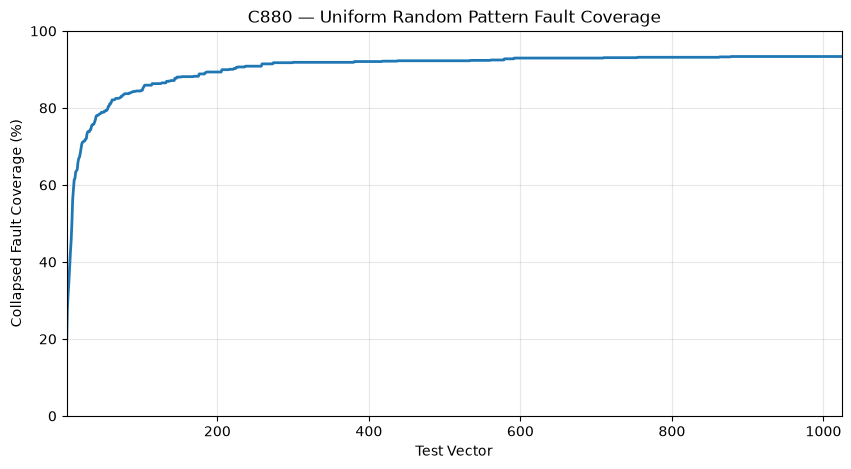

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    coverage_df["vector_id"],
    coverage_df["fault_coverage_percent"],
    linewidth=2
)

plt.xlabel("Test Vector")
plt.ylabel("Collapsed Fault Coverage (%)")
plt.title("C880 — Uniform Random Pattern Fault Coverage")

plt.grid(True, alpha=0.3)
plt.xlim(1, N_VECTORS)
plt.ylim(0, 100)

plt.show()


In [ ]:
fault_results_df.to_csv(
    "c880_scenario1_fault_simulation.csv",
    index=False
)

fault_summary.to_csv(
    "c880_scenario1_fault_summary.csv",
    index=False
)

coverage_df.to_csv(
    "c880_scenario1_coverage_curve.csv",
    index=False
)

print("Scenario 1 fault-simulation results saved.")


Scenario 1 fault-simulation results saved.


Stage 2 assigning weigths to POs

In [ ]:
PO_WEIGHTS = {
    str(po): 1.0
    for po in circuit.outputs
}

print("PO weights:")

for po, weight in PO_WEIGHTS.items():
    print(f"PO {po}: {weight}")


PO weights:
PO 388: 1.0
PO 389: 1.0
PO 390: 1.0
PO 391: 1.0
PO 418: 1.0
PO 419: 1.0
PO 420: 1.0
PO 421: 1.0
PO 422: 1.0
PO 423: 1.0
PO 446: 1.0
PO 447: 1.0
PO 448: 1.0
PO 449: 1.0
PO 450: 1.0
PO 767: 1.0
PO 768: 1.0
PO 850: 1.0
PO 863: 1.0
PO 864: 1.0
PO 865: 1.0
PO 866: 1.0
PO 874: 1.0
PO 878: 1.0
PO 879: 1.0
PO 880: 1.0


In [83]:
import ast


def load_signal_impact(filename):
    """
    Load signal_impact.csv.

    The file contains a final field, reachable_POs, that itself
    contains commas inside a Python-style list.

    Example:

        ..., 57.6923, "['418', '419', '446', ...]"

    Therefore we split each data line only 8 times.
    """

    impact = {}

    with open(
        filename,
        "r",
        encoding="utf-8"
    ) as f:

        # -----------------------------------------------------
        # Read header
        # -----------------------------------------------------

        header = f.readline().strip()

        columns = [
            x.strip()
            for x in header.split(",")
        ]

        print("Columns detected:")
        print(columns)

        # We expect exactly 9 logical columns
        expected_columns = [
            "rank",
            "signal",
            "gate",
            "level",
            "fanout",
            "PO_count",
            "PO_impact",
            "PO_impact_%",
            "reachable_POs"
        ]

        if columns != expected_columns:

            raise ValueError(
                "Unexpected signal_impact.csv header.\n"
                f"Expected: {expected_columns}\n"
                f"Found:    {columns}"
            )

        # -----------------------------------------------------
        # Read data
        # -----------------------------------------------------

        for line_number, raw_line in enumerate(
            f,
            start=2
        ):

            line = raw_line.strip()

            if not line:
                continue

            # -------------------------------------------------
            # IMPORTANT:
            #
            # Split ONLY the first 8 commas.
            #
            # Everything after that belongs to reachable_POs.
            # -------------------------------------------------

            parts = line.split(",", 8)

            if len(parts) != 9:

                raise ValueError(
                    f"Could not parse line {line_number}.\n"
                    f"Expected 9 fields, got {len(parts)}:\n"
                    f"{line}"
                )

            (
                rank_text,
                signal_text,
                gate_text,
                level_text,
                fanout_text,
                po_count_text,
                po_impact_text,
                po_impact_percent_text,
                reachable_text
            ) = parts

            # -------------------------------------------------
            # Clean normal fields
            # -------------------------------------------------

            rank_text = rank_text.strip()
            signal_text = signal_text.strip()
            gate_text = gate_text.strip()
            level_text = level_text.strip()
            fanout_text = fanout_text.strip()
            po_count_text = po_count_text.strip()
            po_impact_text = po_impact_text.strip()
            po_impact_percent_text = po_impact_percent_text.strip()
            reachable_text = reachable_text.strip()

            # -------------------------------------------------
            # Remove surrounding CSV quotes from reachable_POs
            # -------------------------------------------------

            if (
                len(reachable_text) >= 2
                and reachable_text[0] == '"'
                and reachable_text[-1] == '"'
            ):
                reachable_text = reachable_text[1:-1]

            reachable_text = reachable_text.strip()

            # -------------------------------------------------
            # Parse reachable PO list
            # -------------------------------------------------

            try:

                reachable_pos = ast.literal_eval(
                    reachable_text
                )

            except (ValueError, SyntaxError) as e:

                raise ValueError(
                    f"Could not parse reachable_POs "
                    f"for signal {signal_text} "
                    f"on line {line_number}.\n\n"
                    f"Raw field:\n"
                    f"{reachable_text}"
                ) from e

            # -------------------------------------------------
            # Verify that it really is a list
            # -------------------------------------------------

            if not isinstance(
                reachable_pos,
                list
            ):

                raise ValueError(
                    f"reachable_POs for signal "
                    f"{signal_text} is not a list.\n"
                    f"Value: {reachable_pos!r}"
                )

            # -------------------------------------------------
            # Normalize PO names
            # -------------------------------------------------

            reachable_pos = [
                str(po).strip()
                for po in reachable_pos
            ]

            # -------------------------------------------------
            # Store
            # -------------------------------------------------

            signal = signal_text

            impact[signal] = {

                "rank": int(
                    rank_text
                ),

                "gate": gate_text,

                "level": int(
                    level_text
                ),

                "fanout": int(
                    fanout_text
                ),

                "PO_count": int(
                    po_count_text
                ),

                "PO_impact": float(
                    po_impact_text
                ),

                "PO_impact_%": float(
                    po_impact_percent_text
                ),

                "reachable_POs": reachable_pos
            }

    return impact


In [84]:
signal_impact=load_signal_impact("signal_impact.csv")
print(    "Signals loaded:",    len(signal_impact))
print(    signal_impact["1"])


Columns detected:
['rank', 'signal', 'gate', 'level', 'fanout', 'PO_count', 'PO_impact', 'PO_impact_%', 'reachable_POs']
Signals loaded: 443
{'rank': 1, 'gate': '', 'level': 0, 'fanout': 6, 'PO_count': 15, 'PO_impact': 0.5769230769230769, 'PO_impact_%': 57.692307692307686, 'reachable_POs': ['418', '419', '446', '447', '448', '449', '850', '863', '864', '865', '866', '874', '878', '879', '880']}


In [52]:
with open("signal_impact.csv", "r") as f:
    for i in range(5):
        print(repr(f.readline()))


'rank, signal, gate, level, fanout, PO_count, PO_impact           , PO_impact_%        , reachable_POs\n'
'   1,      1,     ,     0,      6,       15, 0.5769230769230769  , 57.692307692307686 , "[\'418\', \'419\', \'446\', \'447\', \'448\', \'449\', \'850\', \'863\', \'864\', \'865\', \'866\', \'874\', \'878\', \'879\', \'880\']"\n'
'   2,     29,     ,     0,      6,       15, 0.5769230769230769  , 57.692307692307686 , "[\'388\', \'389\', \'390\', \'419\', \'446\', \'448\', \'850\', \'863\', \'864\', \'865\', \'866\', \'874\', \'878\', \'879\', \'880\']"\n'
'   3,     42,     ,     0,      8,       14, 0.5384615384615384  , 53.84615384615385  , "[\'388\', \'390\', \'419\', \'422\', \'446\', \'850\', \'863\', \'864\', \'865\', \'866\', \'874\', \'878\', \'879\', \'880\']"\n'
'   4,     59,     ,     0,      8,       13, 0.5                 , 50.0               , "[\'420\', \'421\', \'422\', \'449\', \'850\', \'863\', \'864\', \'865\', \'866\', \'874\', \'878\', \'879\', \'880\']"\n'


In [85]:
for signal in ["1", "29", "42", "59", "13"]:

    info = signal_impact[signal]

    print()
    print("SIGNAL:", signal)
    print("PO_count field :", info["PO_count"])
    print("reachable_POs :", info["reachable_POs"])
    print("type           :", type(info["reachable_POs"]))
    print("length         :", len(info["reachable_POs"]))



SIGNAL: 1
PO_count field : 15
reachable_POs : ['418', '419', '446', '447', '448', '449', '850', '863', '864', '865', '866', '874', '878', '879', '880']
type           : <class 'list'>
length         : 15

SIGNAL: 29
PO_count field : 15
reachable_POs : ['388', '389', '390', '419', '446', '448', '850', '863', '864', '865', '866', '874', '878', '879', '880']
type           : <class 'list'>
length         : 15

SIGNAL: 42
PO_count field : 14
reachable_POs : ['388', '390', '419', '422', '446', '850', '863', '864', '865', '866', '874', '878', '879', '880']
type           : <class 'list'>
length         : 14

SIGNAL: 59
PO_count field : 13
reachable_POs : ['420', '421', '422', '449', '850', '863', '864', '865', '866', '874', '878', '879', '880']
type           : <class 'list'>
length         : 13

SIGNAL: 13
PO_count field : 13
reachable_POs : ['418', '419', '446', '448', '449', '850', '863', '864', '865', '874', '878', '879', '880']
type           : <class 'list'>
length         : 13


In [86]:
def validate_signal_impact(signal_impact):

    errors = []

    for signal, info in signal_impact.items():

        po_count = info["PO_count"]
        actual_count = len(
            info["reachable_POs"]
        )

        if po_count != actual_count:

            errors.append(
                f"Signal {signal}: "
                f"PO_count={po_count}, "
                f"reachable_POs={actual_count}"
            )

    if errors:

        print(
            "SIGNAL IMPACT VALIDATION FAILED"
        )

        for error in errors:
            print("  -", error)

        raise ValueError(
            "Signal impact contains inconsistent "
            "PO reachability information."
        )

    print(
        "Signal impact validation PASSED."
    )

    print(
        f"Signals validated: "
        f"{len(signal_impact)}"
    )


In [87]:
validate_signal_impact(
    signal_impact
)


Signal impact validation PASSED.
Signals validated: 443


In [92]:
def calculate_signal_weights(
    signal_impact,
    total_po_count
):
    """
    Calculate signal weights based on PO reachability.

    Weight =
        number of reachable POs / total number of POs

    Parameters
    ----------
    signal_impact : dict
        Parsed signal impact information.

    total_po_count : int
        Total number of primary outputs in the circuit.

    Returns
    -------
    dict
        signal -> weight
    """

    if total_po_count <= 0:
        raise ValueError(
            "total_po_count must be greater than zero"
        )

    weights = {}

    for signal, data in signal_impact.items():

        po_count = int(data["PO_count"])

        weight = po_count / total_po_count

        # Keep weight within [0, 1]
        weight = max(0.0, min(1.0, weight))

        weights[str(signal)] = weight

    return weights


In [95]:
TOTAL_PO_COUNT = len(circuit.outputs)

print("Total POs:", TOTAL_PO_COUNT)

signal_weights = calculate_signal_weights(
    signal_impact,
    total_po_count=TOTAL_PO_COUNT
)


Total POs: 26


In [96]:
for signal in ["1", "29", "42", "59", "13"]:

    print(
        f"Signal {signal}: "
        f"PO_count={signal_impact[signal]['PO_count']}, "
        f"weight={signal_weights[signal]:.4f}"
    )


Signal 1: PO_count=15, weight=0.5769
Signal 29: PO_count=15, weight=0.5769
Signal 42: PO_count=14, weight=0.5385
Signal 59: PO_count=13, weight=0.5000
Signal 13: PO_count=13, weight=0.5000
